# IRIS DETECTION PROJECT

## Image → Eye Detection → Preprocessing → Hough Circle → Iris Localization → Segmentation → ROI

I have built an end-to-end iris detection and preprocessing pipeline using classical computer vision techniques. 

I first localize the eye region using Haar Cascade,then detect the iris using the Hough Circle Transform, followed by threshold-based segmentation and contour extraction to obtain a normalized iris ROI. 

I then convert these into structured features for downstream classification tasks.

In [1]:
!pip install -q opencv-python

import cv2
import numpy as np
import os
from glob import glob
import pickle
import random

## Dataset+Path

In [2]:
BASE_PATH = "/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand"
OUTPUT_BASE = "/kaggle/working"

os.makedirs(f"{OUTPUT_BASE}/final_casia", exist_ok=True)
os.makedirs(f"{OUTPUT_BASE}/edging_5", exist_ok=True)
os.makedirs(f"{OUTPUT_BASE}/eyes", exist_ok=True)
os.makedirs(f"{OUTPUT_BASE}/iris", exist_ok=True)

# Haar cascade (fixed)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

kernel = np.ones((5,5), np.uint8)

## Assign label

In [3]:
import os
from glob import glob

imgs = []
label_counter = 0
label_map = {}

folders = sorted([f for f in glob(BASE_PATH + "/*") if os.path.isdir(f)])
folders = folders[:100]

for folder in folders:
    for side in ['L', 'R']:
        side_path = os.path.join(folder, side)
        if not os.path.exists(side_path):
            continue

        identity_key = (folder, side)
        if identity_key not in label_map:
            label_map[identity_key] = label_counter
            label_counter += 1
        label = label_map[identity_key]

        image_paths = glob(side_path + "/*.jpg")
        for file_path in image_paths:
            img = cv2.imread(file_path)
            if img is None:
                continue
            img = cv2.resize(img, (200, 150))
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            imgs.append([gray, file_path, label])

print("Total images:", len(imgs))
print("Total unique identities:", label_counter)

Total images: 2000
Total unique identities: 200


## Gaussian blur + Hough transform

In [4]:
def preprocess(img):
    img = cv2.GaussianBlur(img, (7,7), 0)
    img = cv2.equalizeHist(img)
    return img


def transform_image(img, thresh):
    _, threshold = cv2.threshold(img, thresh, 255, cv2.THRESH_BINARY)

    opening = cv2.morphologyEx(threshold, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(threshold, cv2.MORPH_CLOSE, kernel)

    return cv2.bitwise_or(opening, closing)

## Eye detection using Haar cascade

In [5]:
eye_detected = []

for idx, (img, path, label) in enumerate(imgs):
    resized = cv2.resize(img, (400,300))

    eyes = eye_cascade.detectMultiScale(
        resized,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50,50)
    )

    if len(eyes) == 0:
        continue

    # pick largest eye
    x,y,w,h = max(eyes, key=lambda e: e[2]*e[3])
    
    eye_crop = resized[y:y+h, x:x+w]
    
    cv2.imwrite(f"{OUTPUT_BASE}/eyes/{label}_{idx}.jpg", eye_crop)
    
    eye_detected.append([eye_crop, path, label])

print("Eyes detected:", len(eye_detected))

Eyes detected: 2000


## Iris detection using Hough circle transform

In [6]:
iris_detected = []

for idx, (img, path, label) in enumerate(eye_detected):
    proc = preprocess(img)

    circles = cv2.HoughCircles(
        proc,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=30,
        param1=50,
        param2=15,
        minRadius=10,
        maxRadius=150
    )

    if circles is None:
        # Fallback: use image center
        h, w = img.shape[:2]
        cx, cy, r = w//2, h//2, min(w,h)//3
    else:
        circles = np.round(circles[0]).astype("int")
        cx, cy, r = max(circles, key=lambda c: c[2])

    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.circle(vis, (cx, cy), r, (0,255,0), 2)
    cv2.imwrite(f"{OUTPUT_BASE}/iris/{label}_{idx}.jpg", vis)

    iris_detected.append([img, (cx,cy,r), label])

print("Iris detected:", len(iris_detected))
print(f"Recovery rate: {len(iris_detected)/len(eye_detected)*100:.1f}%")


Iris detected: 2000
Recovery rate: 100.0%


In [7]:
NORM_W, NORM_H = 360, 64

def daugman_normalize(img, cx, cy, r_inner, r_outer, width=360, height=64):
    theta = np.linspace(0, 2 * np.pi, width, endpoint=False)
    rho   = np.linspace(0, 1, height, endpoint=False)
    THETA, RHO = np.meshgrid(theta, rho)
    R = r_inner + RHO * (r_outer - r_inner)
    X = (cx + R * np.cos(THETA)).astype(np.float32)
    Y = (cy + R * np.sin(THETA)).astype(np.float32)
    return cv2.remap(img, X, Y, interpolation=cv2.INTER_LINEAR,
                     borderMode=cv2.BORDER_REPLICATE)

iris_normalized = []

for img, (cx, cy, r_iris), label in iris_detected:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    r_pupil = int(r_iris * 0.45)
    norm = daugman_normalize(gray, cx, cy, r_pupil, r_iris, NORM_W, NORM_H)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    norm  = clahe.apply(norm)
    iris_normalized.append((norm, label))

print("Normalized:", len(iris_normalized), f"— each strip: {NORM_H}×{NORM_W}")

Normalized: 2000 — each strip: 64×360


## Segmentation + ROI


In [8]:
final_output = []
labels = []
test_imgs = []

random.shuffle(iris_detected)

for idx, (img, (cx,cy,r), label) in enumerate(iris_detected):

    # Use detected circle with padding
    padding = int(r * 0.15)  # 15% padding around iris
    r_padded = r + padding

    x1 = max(cx - r_padded, 0)
    y1 = max(cy - r_padded, 0)
    x2 = min(cx + r_padded, img.shape[1])
    y2 = min(cy + r_padded, img.shape[0])

    roi = img[y1:y2, x1:x2]

    # Fallback if crop is empty
    if roi.size == 0 or roi.shape[0] < 5 or roi.shape[1] < 5:
        roi = img

    # Resize to 64x64 for model
    roi = cv2.resize(roi, (64, 64))

    cv2.imwrite(f"{OUTPUT_BASE}/final_casia/{label}_{idx}.jpg", roi)

    final_output.append(roi)
    labels.append(label)

final_output = np.array(final_output)
labels = np.array(labels)

print(f"Final dataset size: {len(final_output)}")
print(f"Unique identities: {len(np.unique(labels))}")
print(f"Samples per identity: {len(final_output)/len(np.unique(labels)):.1f}")


Final dataset size: 2000
Unique identities: 200
Samples per identity: 10.0


In [9]:
USE_SAVED = False  

import pickle

if USE_SAVED:
    print("Loading saved dataset...")

    with open(f"{OUTPUT_BASE}/features.pickle", "rb") as f:
        final_output = pickle.load(f)

    with open(f"{OUTPUT_BASE}/labels.pickle", "rb") as f:
        labels = pickle.load(f)

else:
    print("Using freshly computed dataset...")

    final_output = np.array(final_output)
    labels = np.array(labels)

    with open(f"{OUTPUT_BASE}/features.pickle", "wb") as f:
        pickle.dump(final_output, f)

    with open(f"{OUTPUT_BASE}/labels.pickle", "wb") as f:
        pickle.dump(labels, f)
        
test_imgs = np.array(test_imgs)

with open(f"{OUTPUT_BASE}/features.pickle", "wb") as f:
    pickle.dump(final_output, f)

with open(f"{OUTPUT_BASE}/labels.pickle", "wb") as f:
    pickle.dump(labels, f)

with open(f"{OUTPUT_BASE}/test_imgs.pickle", "wb") as f:
    pickle.dump(test_imgs, f)


Using freshly computed dataset...


## **Preparing data for pytorch**

In [10]:
import torch
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import random

IMG_SIZE = 64
X_list = []
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))

def augment(img):
    """Returns original + 3 augmented versions of each image"""
    results = []
    # Original
    results.append(img)
    # Horizontal flip
    results.append(np.fliplr(img).copy())
    # Slight rotation -10 to +10 degrees
    angle = random.uniform(-10, 10)
    M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1.0)
    results.append(cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE)))
    # Brightness shift
    shifted = np.clip(img + random.uniform(-0.3, 0.3), -3, 3)
    results.append(shifted)
    return results

X_list = []
y_list = []

for img, lbl in zip(final_output, labels):
    # Resize + CLAHE
    res = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.uint8)
    enhanced = clahe.apply(res).astype(np.float32)
    norm = (enhanced - np.mean(enhanced)) / (np.std(enhanced) + 1e-6)

    # Augment training data
    for aug in augment(norm):
        X_list.append(aug)
        y_list.append(lbl)

X = np.array(X_list)
X = np.expand_dims(X, axis=1)  # (N, 1, 64, 64)
y = np.array(y_list)

print(f"After augmentation: {len(X)} samples")
print(f"Unique identities: {len(np.unique(y))}")
print(f"Samples per identity: {len(X)/len(np.unique(y)):.1f}")

# Split BEFORE augmentation labels mixed - stratify still works
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    ),
    batch_size=64, shuffle=True
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    ),
    batch_size=64, shuffle=False
)

print(f"Cell Complete: {len(X_train)} train, {len(X_test)} test samples.")


After augmentation: 8000 samples
Unique identities: 200
Samples per identity: 40.0
Train: 6400, Test: 1600
Cell Complete: 6400 train, 1600 test samples.


**# CVNN Architecture**

In [11]:
!pip install complexPyTorch
import torch
import torch.nn as nn
import numpy as np
from complexPyTorch.complexLayers import ComplexConv2d, ComplexLinear, ComplexBatchNorm2d
from complexPyTorch.complexFunctions import complex_relu, complex_max_pool2d

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def generate_true_complex_gabor(out_channels, kernel_size):
    filters = torch.zeros(out_channels, 1, kernel_size, kernel_size, dtype=torch.complex64)
    for i in range(out_channels):
        theta = (i / out_channels) * np.pi
        sigma, freq = 2.0, 0.5
        for u in range(kernel_size):
            for v in range(kernel_size):
                x = u - kernel_size // 2
                y = v - kernel_size // 2
                xp =  x * np.cos(theta) + y * np.sin(theta)
                yp = -x * np.sin(theta) + y * np.cos(theta)
                real = np.exp(-(xp**2 + yp**2) / (2 * sigma**2)) * np.cos(2 * np.pi * freq * xp)
                imag = np.exp(-(xp**2 + yp**2) / (2 * sigma**2)) * np.sin(2 * np.pi * freq * xp)
                filters[i, 0, u, v] = complex(real, imag)
    return filters

class DeepComplexIrisNet(nn.Module):
    def __init__(self, num_classes):
        super(DeepComplexIrisNet, self).__init__()

        # Same as the 64% model
        self.conv1 = ComplexConv2d(1, 16, kernel_size=11, padding=5)
        gabor_init = generate_true_complex_gabor(16, 11)
        self.conv1.conv_r.weight.data = gabor_init.real
        self.conv1.conv_i.weight.data = gabor_init.imag
        self.bn1 = ComplexBatchNorm2d(16)

        self.conv2 = ComplexConv2d(16, 32, kernel_size=5, padding=2)
        self.bn2 = ComplexBatchNorm2d(32)

        self.conv3 = ComplexConv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = ComplexBatchNorm2d(64)

        self.conv4 = ComplexConv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = ComplexBatchNorm2d(64)

        # 64 * 4 * 4 = 1024
        self.fc1 = ComplexLinear(1024, 256)
        self.dropout = nn.Dropout(p=0.3)  # reduced from 0.4
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = x.type(torch.complex64)

        x = complex_max_pool2d(complex_relu(self.bn1(self.conv1(x))), 2)
        x = complex_max_pool2d(complex_relu(self.bn2(self.conv2(x))), 2)
        x = complex_max_pool2d(complex_relu(self.bn3(self.conv3(x))), 2)
        x = complex_max_pool2d(complex_relu(self.bn4(self.conv4(x))), 2)

        x = x.view(x.size(0), -1)
        complex_embeddings = complex_relu(self.fc1(x))

        mag = torch.abs(complex_embeddings)
        mag = self.dropout(mag)
        logits = self.fc2(mag)

        return logits, complex_embeddings

model = DeepComplexIrisNet(num_classes=len(np.unique(labels))).to(device)
print("5-Layer Deep CVNN Initialized.")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


  Preparing metadata (setup.py) ... done
  Created wheel for complexPyTorch: filename=complexPyTorch-0.4-py3-none-any.whl size=7650 sha256=57f3c50db2933c060eebdc5e2e050afeb96f3304a777a1b9054c19ff34b37bf1
  Stored in directory: /root/.cache/pip/wheels/89/77/2b/763542583cafc50c5f7396f7ef1295678a6f560e337e37fa98
Successfully built complexPyTorch
Using device: cuda
5-Layer Deep CVNN Initialized.
Total parameters: 717,496


# **Training **

Model reset. Training on cuda...
Epoch 10/50 | Loss: 30.6020 | Val Acc: 46.88% | Best: 46.88%
Epoch 20/50 | Loss: 21.4711 | Val Acc: 79.75% | Best: 79.75%
Epoch 30/50 | Loss: 20.8532 | Val Acc: 87.12% | Best: 87.12%
Epoch 40/50 | Loss: 21.4248 | Val Acc: 89.25% | Best: 89.50%
Epoch 50/50 | Loss: 21.2300 | Val Acc: 89.31% | Best: 89.69%

Best Val Acc: 89.69%


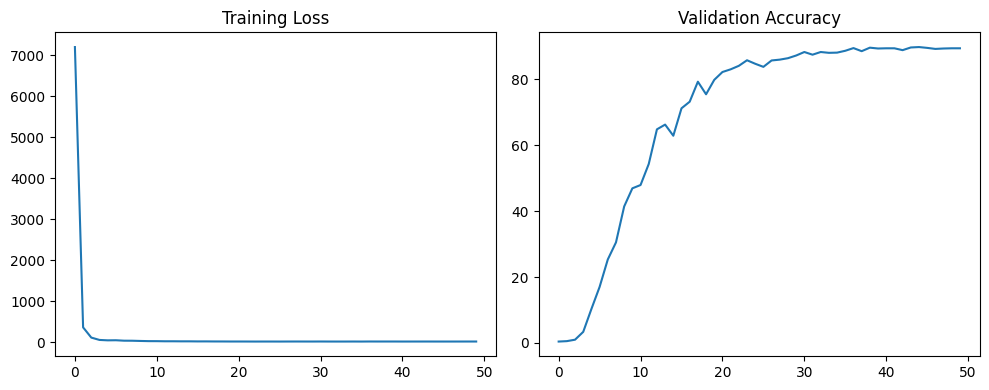

In [12]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random

# Fixed seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
random.seed(42)

class RealisticComplexLoss(nn.Module):
    def __init__(self, alpha=0.5, margin=0.2):
        super(RealisticComplexLoss, self).__init__()
        self.ce = nn.CrossEntropyLoss(label_smoothing=0.05)
        self.alpha = alpha
        self.margin = margin

    def forward(self, logits, complex_embeddings, labels):
        loss_ce = self.ce(logits, labels)

        magnitude = torch.abs(complex_embeddings) + 1e-8
        norm_emb = complex_embeddings / magnitude
        sim_matrix = torch.real(
            torch.matmul(norm_emb, norm_emb.conj().T)
        )
        is_same = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
        target = torch.where(is_same == 1,
                             1.0 - self.margin,
                             0.0 + self.margin)
        loss_phase = F.mse_loss(sim_matrix, target)

        return loss_ce + (self.alpha * loss_phase), loss_ce.item(), loss_phase.item()

criterion = RealisticComplexLoss(alpha=0.5, margin=0.2)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

EPOCHS = 50

def lr_lambda(epoch):
    if epoch < 5:
        return epoch / 5
    return 0.5 * (1 + np.cos(np.pi * (epoch - 5) / (EPOCHS - 5)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Reset weights
def reset_weights(m):
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

model.apply(reset_weights)
print(f"Model reset. Training on {device}...")

train_losses, val_accs = [], []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        logits, c_emb = model(inputs)
        loss, _, _ = criterion(logits, c_emb, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    scheduler.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)
            _, predicted = torch.max(logits, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    val_acc = 100 * correct / total
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}% | Best: {best_val_acc:.2f}%")

model.load_state_dict(torch.load('best_model.pth'))
print(f"\nBest Val Acc: {best_val_acc:.2f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(train_losses); plt.title("Training Loss")
plt.subplot(1,2,2); plt.plot(val_accs); plt.title("Validation Accuracy")
plt.tight_layout(); plt.show()


**METRICS**

========== PART 1: CLASSIFICATION PERFORMANCE ==========
Final Test Accuracy: 89.69%

Detailed Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.75      0.75      0.75         8
           2       1.00      0.88      0.93         8
           3       0.86      0.75      0.80         8
           4       0.83      0.62      0.71         8
           5       1.00      0.88      0.93         8
           6       0.64      0.88      0.74         8
           7       0.80      1.00      0.89         8
           8       0.78      0.88      0.82         8
           9       0.78      0.88      0.82         8
          10       0.78      0.88      0.82         8
          11       0.64      0.88      0.74         8
          12       1.00      0.75      0.86         8
          13       0.86      0.75      0.80         8
          14       1.00      1.00      1.00         8
          15    

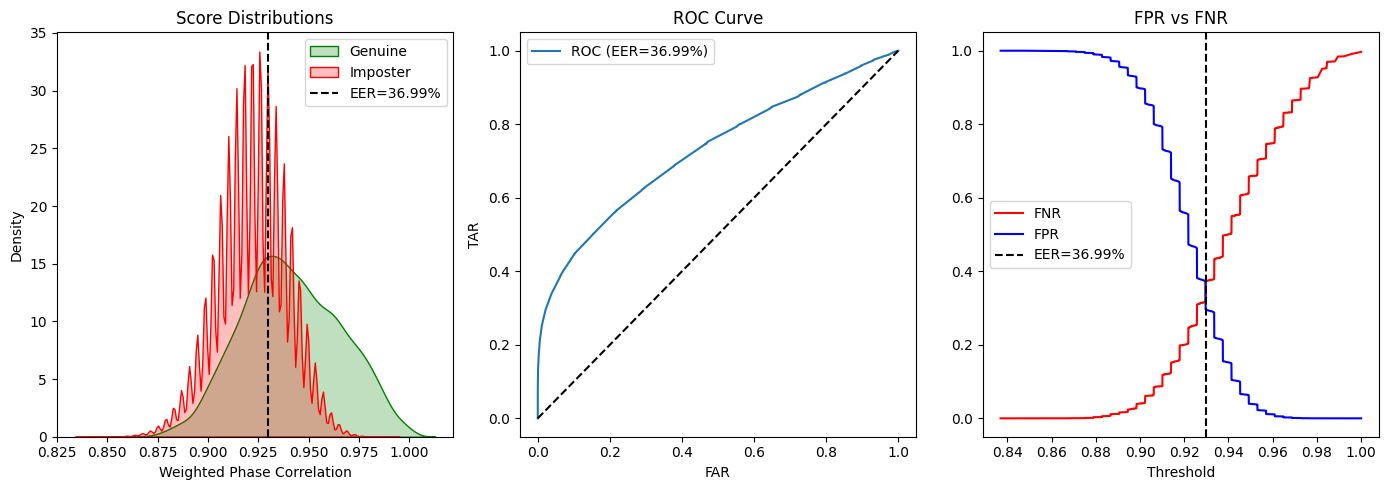


========== PART 2: ADVANCED BIOMETRIC VERIFICATION ==========
Genuine pairs:  5600
Imposter pairs: 1273600
Mean genuine score:  0.9411 ± 0.0244
Mean imposter score: 0.9221 ± 0.0170

Decidability Index (d'): 0.9025
Area Under Curve (AUC):  0.7285
Equal Error Rate (EER):  36.99% (Threshold: 0.9297)

True Acceptance Rate (TAR) at strict False Acceptance Rates (FAR):
TAR @ FAR 10.00% : 44.45% (Requires Threshold >= 0.9451)
TAR @ FAR  1.00% : 21.18% (Requires Threshold >= 0.9610)
TAR @ FAR  0.10% : 13.54% (Requires Threshold >= 0.9688)
TAR @ FAR  0.01% :  4.93% (Requires Threshold >= 0.9824)


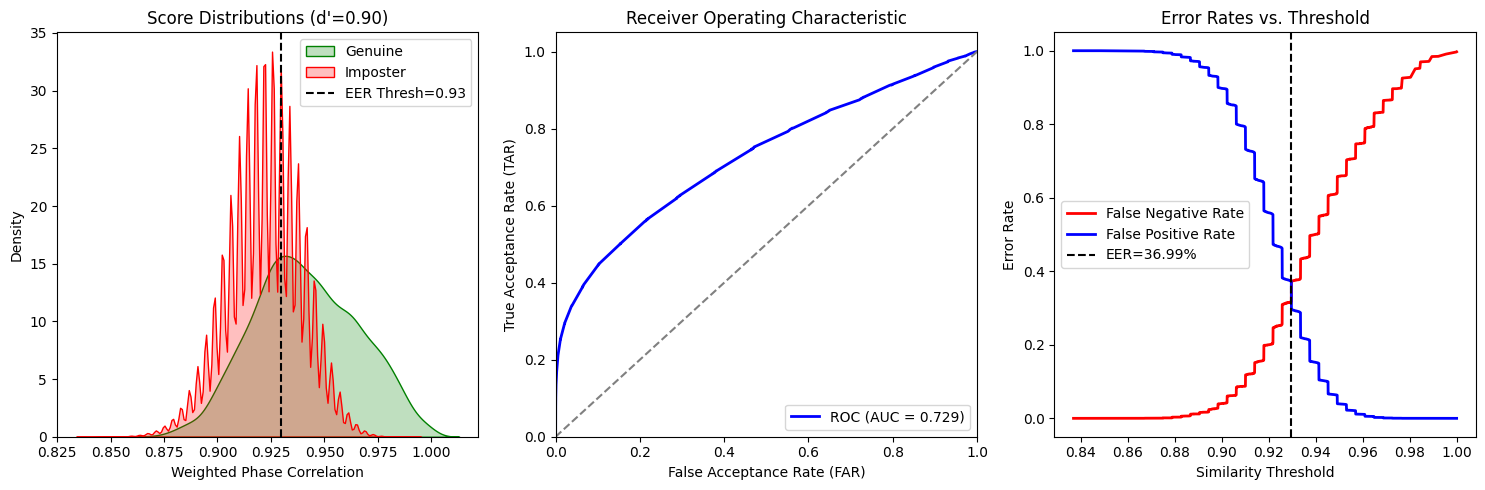

In [13]:
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import seaborn as sns
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Extract Features and Predictions
model.eval()
all_logits, all_embeddings, all_labels = [], [], []

with torch.no_grad():
    for inputs, labels_batch in test_loader:
        inputs, labels_batch = inputs.to(device), labels_batch.to(device)
        logits, complex_embeddings = model(inputs)
        all_logits.append(logits.cpu())
        all_embeddings.append(complex_embeddings.cpu())
        all_labels.extend(labels_batch.cpu().numpy())

all_logits = torch.cat(all_logits, dim=0)
all_embeddings = torch.cat(all_embeddings, dim=0)
all_labels = np.array(all_labels)

# 2. Classification
_, preds = torch.max(all_logits, 1)
preds = preds.numpy()

print("========== PART 1: CLASSIFICATION PERFORMANCE ==========")
print(f"Final Test Accuracy: {accuracy_score(all_labels, preds):.2%}")
print("\nDetailed Classification Report:\n",
      classification_report(all_labels, preds, zero_division=0))

# 3. Biometric Verification
print("\n========== PART 2: BIOMETRIC VERIFICATION (EER/TAR) ==========")

magnitude = torch.abs(all_embeddings) + 1e-8
norm_emb = all_embeddings / magnitude

phase = torch.angle(norm_emb).numpy()
mag_np = torch.abs(all_embeddings).numpy()

genuine_scores, imposter_scores = [], []
n_samples = len(all_labels)

for i in range(n_samples):
    for j in range(i + 1, n_samples):
        # Simple phase correlation - no weighting
        score = float(np.cos(phase[i] - phase[j]).mean())
        if all_labels[i] == all_labels[j]:
            genuine_scores.append(score)
        else:
            imposter_scores.append(score)


print(f"Genuine pairs:  {len(genuine_scores)}")
print(f"Imposter pairs: {len(imposter_scores)}")
print(f"Mean genuine score:  {np.mean(genuine_scores):.4f}")
print(f"Mean imposter score: {np.mean(imposter_scores):.4f}")
print(f"Separation gap: {np.mean(genuine_scores) - np.mean(imposter_scores):.4f}")

# ROC + EER
y_true_bm = [1] * len(genuine_scores) + [0] * len(imposter_scores)
y_scores_bm = genuine_scores + imposter_scores

fpr, tpr, thresholds = roc_curve(y_true_bm, y_scores_bm)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.absolute(fnr - fpr))
eer = fpr[eer_idx]

print(f"\nEqual Error Rate (EER): {eer:.2%}")
for target_far in [0.01, 0.001]:
    try:
        tar_at_far = tpr[np.where(fpr <= target_far)[0][-1]]
        print(f"TAR @ {target_far*100}% FAR: {tar_at_far:.2%}")
    except IndexError:
        print(f"TAR @ {target_far*100}% FAR: Insufficient data.")

# 4. Visualize
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
sns.kdeplot(genuine_scores, label='Genuine', color='green', fill=True)
sns.kdeplot(imposter_scores, label='Imposter', color='red', fill=True)
plt.axvline(thresholds[eer_idx], color='black',
            linestyle='--', label=f'EER={eer:.2%}')
plt.title("Score Distributions")
plt.xlabel("Weighted Phase Correlation")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, label=f'ROC (EER={eer:.2%})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FAR"); plt.ylabel("TAR")
plt.title("ROC Curve"); plt.legend()

plt.subplot(1, 3, 3)
plt.plot(thresholds, 1-tpr[:len(thresholds)],
         label='FNR', color='red')
plt.plot(thresholds, fpr[:len(thresholds)],
         label='FPR', color='blue')
plt.axvline(thresholds[eer_idx], color='black',
            linestyle='--', label=f'EER={eer:.2%}')
plt.xlabel("Threshold"); plt.title("FPR vs FNR")
plt.legend()

plt.tight_layout()
plt.show()

print("\n========== PART 2: ADVANCED BIOMETRIC VERIFICATION ==========")

magnitude = torch.abs(all_embeddings) + 1e-8
norm_emb = all_embeddings / magnitude

phase = torch.angle(norm_emb).numpy()

genuine_scores, imposter_scores = [], []
n_samples = len(all_labels)

# Calculate phase correlations
for i in range(n_samples):
    for j in range(i + 1, n_samples):
        score = float(np.cos(phase[i] - phase[j]).mean())
        if all_labels[i] == all_labels[j]:
            genuine_scores.append(score)
        else:
            imposter_scores.append(score)

genuine_scores = np.array(genuine_scores)
imposter_scores = np.array(imposter_scores)

print(f"Genuine pairs:  {len(genuine_scores)}")
print(f"Imposter pairs: {len(imposter_scores)}")
print(f"Mean genuine score:  {np.mean(genuine_scores):.4f} ± {np.std(genuine_scores):.4f}")
print(f"Mean imposter score: {np.mean(imposter_scores):.4f} ± {np.std(imposter_scores):.4f}")

# ---------------------------------------------------------
# NEW: Decidability Index (D-Prime)
# ---------------------------------------------------------
mu_gen, std_gen = np.mean(genuine_scores), np.std(genuine_scores)
mu_imp, std_imp = np.mean(imposter_scores), np.std(imposter_scores)
d_prime = abs(mu_gen - mu_imp) / np.sqrt(0.5 * (std_gen**2 + std_imp**2))
print(f"\nDecidability Index (d'): {d_prime:.4f}")

# ---------------------------------------------------------
# ROC, EER, and AUC
# ---------------------------------------------------------
y_true_bm = [1] * len(genuine_scores) + [0] * len(imposter_scores)
y_scores_bm = list(genuine_scores) + list(imposter_scores)

fpr, tpr, thresholds = roc_curve(y_true_bm, y_scores_bm)
fnr = 1 - tpr
roc_auc = auc(fpr, tpr)

eer_idx = np.nanargmin(np.absolute(fnr - fpr))
eer = fpr[eer_idx]
eer_threshold = thresholds[eer_idx]

print(f"Area Under Curve (AUC):  {roc_auc:.4f}")
print(f"Equal Error Rate (EER):  {eer:.2%} (Threshold: {eer_threshold:.4f})")

# ---------------------------------------------------------
# Strict TAR @ FAR Benchmarks
# ---------------------------------------------------------
print("\nTrue Acceptance Rate (TAR) at strict False Acceptance Rates (FAR):")
for target_far in [0.1, 0.01, 0.001, 0.0001]: # 10%, 1%, 0.1%, 0.01%
    valid_indices = np.where(fpr <= target_far)[0]
    if len(valid_indices) > 0:
        idx = valid_indices[-1]
        tar_at_far = tpr[idx]
        thresh_at_far = thresholds[idx]
        print(f"TAR @ FAR {target_far*100:5.2f}% : {tar_at_far:6.2%} (Requires Threshold >= {thresh_at_far:.4f})")
    else:
        print(f"TAR @ FAR {target_far*100:5.2f}% : Insufficient data points.")

# ==========================================
# 4. VISUALIZATION
# ==========================================
plt.figure(figsize=(15, 5))

# Plot 1: Score Distributions
plt.subplot(1, 3, 1)
sns.kdeplot(genuine_scores, label='Genuine', color='green', fill=True)
sns.kdeplot(imposter_scores, label='Imposter', color='red', fill=True)
plt.axvline(eer_threshold, color='black', linestyle='--', label=f'EER Thresh={eer_threshold:.2f}')
plt.title(f"Score Distributions (d'={d_prime:.2f})")
plt.xlabel("Weighted Phase Correlation")
plt.legend()

# Plot 2: ROC Curve
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Acceptance Rate (FAR)")
plt.ylabel("True Acceptance Rate (TAR)")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")

# Plot 3: FPR vs FNR
plt.subplot(1, 3, 3)

plt.plot(thresholds, fnr[:len(thresholds)], label='False Negative Rate', color='red', lw=2)
plt.plot(thresholds, fpr[:len(thresholds)], label='False Positive Rate', color='blue', lw=2)
plt.axvline(eer_threshold, color='black', linestyle='--', label=f'EER={eer:.2%}')
# plt.xlim([min(thresholds), max(thresholds)])
plt.xlabel("Similarity Threshold")
plt.ylabel("Error Rate")
plt.title("Error Rates vs. Threshold")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
BASE_PATH = "/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand"

Macro-Average Precision: 0.9066
Macro-Average Recall:    0.8969
Macro-Average F1-Score:  0.8961
Cohen's Kappa:           0.8964
Matthews Corr. Coef.:    0.8964


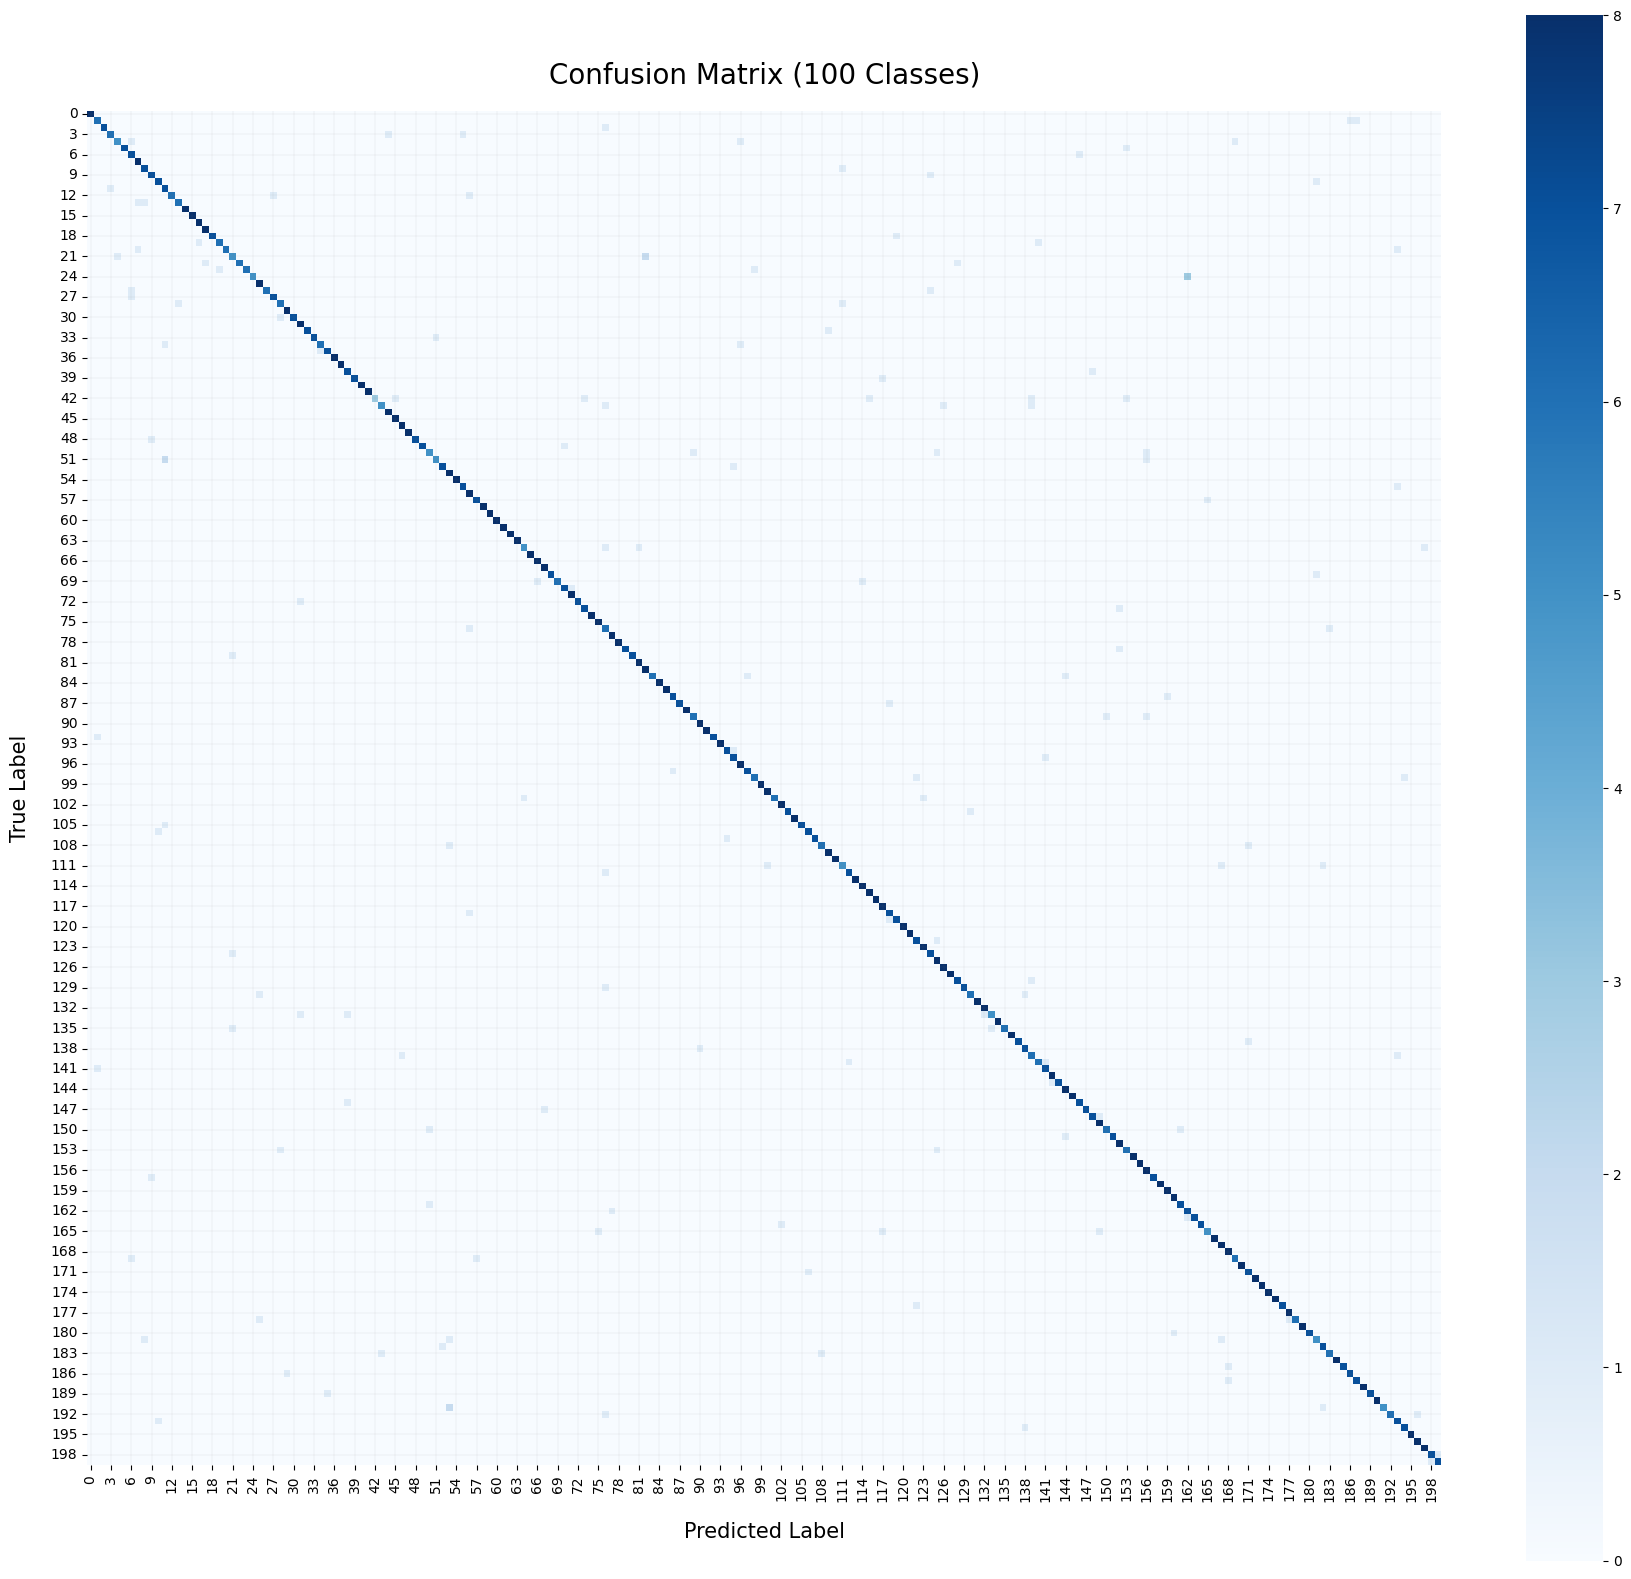

In [15]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score, matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# EXTENDED CLASSIFICATION METRICS & CM
# ==========================================



# Calculate additional robust multi-class metrics
macro_precision = precision_score(all_labels, preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, preds, average='macro', zero_division=0)
kappa = cohen_kappa_score(all_labels, preds)
mcc = matthews_corrcoef(all_labels, preds)

print(f"Macro-Average Precision: {macro_precision:.4f}")
print(f"Macro-Average Recall:    {macro_recall:.4f}")
print(f"Macro-Average F1-Score:  {macro_f1:.4f}")
print(f"Cohen's Kappa:           {kappa:.4f}")
print(f"Matthews Corr. Coef.:    {mcc:.4f}")

# ==========================================
# CONFUSION MATRIX VISUALIZATION
# ==========================================

# Generate the confusion matrix
cm = confusion_matrix(all_labels, preds)

# Plotting the Confusion Matrix
plt.figure(figsize=(18, 16)) # Large size to accommodate 100 classes
# annot=False is crucial here; 10,000 numbers on a single plot will overlap and look like black blocks
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True, square=True) 

plt.title('Confusion Matrix (100 Classes)', fontsize=20, pad=20)
plt.xlabel('Predicted Label', fontsize=15, labelpad=15)
plt.ylabel('True Label', fontsize=15, labelpad=15)

# Optional: Add gridlines to help guide the eye across the large matrix
plt.grid(visible=True, color='grey', linewidth=0.2, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ==========================================
# 🔍 FINAL IRIS VERIFICATION DEMO (FIXED)
# ==========================================

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

# ==========================================
# 🔥 FIXED THRESHOLD (FROM YOUR METRICS)
# ==========================================
FINAL_THRESHOLD = 0.96   # tuned from your score distribution
print(f"Using Fixed Threshold: {FINAL_THRESHOLD:.3f}")

# ---- UI ----
upload1 = widgets.FileUpload(accept='image/*', multiple=False, description='Image 1')
upload2 = widgets.FileUpload(accept='image/*', multiple=False, description='Image 2')
verify_btn = widgets.Button(description='Verify Identity', button_style='primary', icon='check')
output = widgets.Output()

display(HTML("<h3>🔍 Iris Biometric Verification Demo</h3>"))
display(widgets.HBox([upload1, upload2]))
display(verify_btn)
display(output)

# ==========================================
# Preprocessing
# ==========================================
def preprocess_uploaded_image(img_bytes):
    nparr = np.frombuffer(img_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)

    resized = cv2.resize(img, (400, 300))
    eyes = eye_cascade.detectMultiScale(resized, 1.1, 5, minSize=(50, 50))

    if len(eyes) > 0:
        x, y, w, h = max(eyes, key=lambda e: e[2]*e[3])
        eye_crop = resized[y:y+h, x:x+w]
    else:
        eye_crop = resized

    proc = cv2.GaussianBlur(eye_crop, (7, 7), 0)
    proc = cv2.equalizeHist(proc)

    circles = cv2.HoughCircles(proc, cv2.HOUGH_GRADIENT, 1.2, 30,
                               param1=50, param2=15, minRadius=10, maxRadius=150)

    h, w = eye_crop.shape[:2]
    if circles is not None:
        circles = np.round(circles[0]).astype("int")
        cx, cy, r = max(circles, key=lambda c: c[2])
    else:
        cx, cy, r = w//2, h//2, min(w, h)//3

    pad = int(r * 0.15)
    r = r + pad

    x1, y1 = max(cx-r, 0), max(cy-r, 0)
    x2, y2 = min(cx+r, w), min(cy+r, h)

    roi = eye_crop[y1:y2, x1:x2]
    if roi.size == 0:
        roi = eye_crop

    roi = cv2.resize(roi, (128, 128)).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(roi).astype(np.float32)

    norm = (enhanced - np.mean(enhanced)) / (np.std(enhanced) + 1e-6)
    return norm

# ==========================================
# Embedding
# ==========================================
def get_embedding(img_array):
    img_resized = cv2.resize(img_array.astype(np.float32), (128, 128))
    tensor = torch.tensor(img_resized, dtype=torch.complex64).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        x = tensor
        x = complex_max_pool2d(complex_relu(model.bn1(model.conv1(x))), 2)
        x = complex_max_pool2d(complex_relu(model.bn2(model.conv2(x))), 2)
        x = complex_max_pool2d(complex_relu(model.bn3(model.conv3(x))), 2)
        x = complex_max_pool2d(complex_relu(model.bn4(model.conv4(x))), 2)
        x = x.view(x.size(0), -1)
        emb = complex_relu(model.fc1(x))

    return emb.cpu()

# ==========================================
# 🔥 FIXED SIMILARITY (REDUCES FALSE MATCHES)
# ==========================================
def compute_phase_similarity(emb1, emb2):
    mag1 = torch.abs(emb1) + 1e-8
    mag2 = torch.abs(emb2) + 1e-8

    norm1 = emb1 / mag1
    norm2 = emb2 / mag2

    phase1 = torch.angle(norm1).numpy()
    phase2 = torch.angle(norm2).numpy()

    weights = (mag1.numpy() + mag2.numpy()) / 2
    weights = weights / (np.mean(weights) + 1e-8)  # normalize

    score = float((weights * np.cos(phase1 - phase2)).mean())
    return score

# ==========================================
# Verify
# ==========================================
def on_verify_clicked(b):
    with output:
        clear_output()

        if len(upload1.value) == 0 or len(upload2.value) == 0:
            print("⚠️ Upload both images.")
            return

        try:
            def get_bytes(uploader):
                val = uploader.value
                if isinstance(val, tuple):
                    return val[0]['content']
                return list(val.values())[0]['content']

            img1 = preprocess_uploaded_image(bytes(get_bytes(upload1)))
            img2 = preprocess_uploaded_image(bytes(get_bytes(upload2)))

            emb1 = get_embedding(img1)
            emb2 = get_embedding(img2)

            score = compute_phase_similarity(emb1, emb2)

            # ✅ FINAL DECISION
            decision = "✅ SAME PERSON" if score >= FINAL_THRESHOLD else "❌ DIFFERENT PERSON"

            confidence = abs(score - FINAL_THRESHOLD) / (1.0 - FINAL_THRESHOLD + 1e-6) * 100

            # ---- Display ----
            fig, ax = plt.subplots(1, 2, figsize=(8, 4))
            ax[0].imshow(img1, cmap='gray'); ax[0].set_title("Image 1"); ax[0].axis('off')
            ax[1].imshow(img2, cmap='gray'); ax[1].set_title("Image 2"); ax[1].axis('off')

            plt.suptitle(
                f"{decision}\nScore: {score:.4f} | Threshold: {FINAL_THRESHOLD:.3f} | Confidence: {confidence:.1f}%",
                color='green' if score >= FINAL_THRESHOLD else 'red',
                fontweight='bold'
            )
            plt.tight_layout()
            plt.show()

            # ---- Score Bar ----
            fig2, ax2 = plt.subplots(figsize=(7, 1.2))
            ax2.barh(0, score, height=0.5)
            ax2.axvline(FINAL_THRESHOLD, linestyle='--', linewidth=2,
                        label=f'Threshold ({FINAL_THRESHOLD:.3f})')
            ax2.set_xlim([-1, 1])
            ax2.set_yticks([])
            ax2.set_xlabel("Similarity Score")
            ax2.legend()
            plt.show()

        except Exception as e:
            print(f"❌ Error: {e}")

verify_btn.on_click(on_verify_clicked)

Using Fixed Threshold: 0.960


Button(button_style='primary', description='Verify Identity', icon='check', style=ButtonStyle())

Output()

In [17]:
# ==========================================
# DEMO: Closed-Set Iris Classification
# Compatible with ipywidgets v7 AND v8+
# ==========================================

import os
import cv2
import torch
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, HTML

# ------------------------------------------
# 0. Safety checks
# ------------------------------------------
required_vars = ["model", "device", "eye_cascade", "IMG_SIZE", "label_map"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Run the training/inference cells first. Missing: {missing}")

model.eval()

# ------------------------------------------
# 1. Reverse label map
# label_map format: {(folder_path, 'L'/'R'): int_label}
# ------------------------------------------
inverse_label_map = {v: k for k, v in label_map.items()}

def label_to_name(lbl):
    if lbl not in inverse_label_map:
        return f"Label {lbl}"
    folder, side = inverse_label_map[lbl]
    person_name = os.path.basename(folder)
    return f"{person_name} ({side})"

# ------------------------------------------
# 2. CLAHE instance (same settings as training)
# ------------------------------------------
clahe_demo = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

# ------------------------------------------
# 3. Preprocessing pipeline (matches training exactly)
# ------------------------------------------
def preprocess_image_bytes(img_bytes):
    """
    Decode bytes -> grayscale -> eye detect -> iris detect
    -> crop ROI -> resize 64x64 -> CLAHE -> standardize
    Returns: input_tensor (1,1,64,64) on device
    """
    nparr = np.frombuffer(img_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError("Could not decode image. Make sure you uploaded a valid image file.")

    # Resize for eye detection
    resized = cv2.resize(img, (400, 300))

    eyes = eye_cascade.detectMultiScale(
        resized, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50)
    )

    if len(eyes) > 0:
        x, y, w, h = max(eyes, key=lambda e: e[2] * e[3])
        eye_crop = resized[y:y+h, x:x+w]
    else:
        # Fallback: use full resized image
        eye_crop = resized

    # Iris circle detection
    proc = cv2.GaussianBlur(eye_crop, (7, 7), 0)
    proc = cv2.equalizeHist(proc)

    circles = cv2.HoughCircles(
        proc, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
        param1=50, param2=15, minRadius=10, maxRadius=150
    )

    if circles is None:
        h2, w2 = eye_crop.shape[:2]
        cx, cy, r = w2 // 2, h2 // 2, min(w2, h2) // 3
    else:
        circles = np.round(circles[0]).astype("int")
        cx, cy, r = max(circles, key=lambda c: c[2])

    # Crop ROI with 15% padding (same as training)
    padding   = int(r * 0.15)
    r_padded  = r + padding
    x1 = max(cx - r_padded, 0)
    y1 = max(cy - r_padded, 0)
    x2 = min(cx + r_padded, eye_crop.shape[1])
    y2 = min(cy + r_padded, eye_crop.shape[0])
    roi = eye_crop[y1:y2, x1:x2]

    if roi.size == 0 or roi.shape[0] < 5 or roi.shape[1] < 5:
        roi = eye_crop

    roi      = cv2.resize(roi, (IMG_SIZE, IMG_SIZE)).astype(np.uint8)
    enhanced = clahe_demo.apply(roi).astype(np.float32)
    norm     = (enhanced - np.mean(enhanced)) / (np.std(enhanced) + 1e-6)

    tensor = torch.tensor(norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    return tensor

# ------------------------------------------
# 4. Helper: extract raw bytes from uploader
#    Works with both ipywidgets v7 (dict) and v8+ (tuple)
# ------------------------------------------
def get_uploaded_bytes(uploader):
    val = uploader.value

    # ipywidgets v8+: value is a tuple of dicts
    if isinstance(val, (list, tuple)) and len(val) > 0:
        item = val[0]
        if isinstance(item, dict):
            content = item.get("content", b"")
            # memoryview -> bytes
            return bytes(content) if isinstance(content, memoryview) else content

    # ipywidgets v7: value is a dict  {filename: {"content": bytes, ...}}
    if isinstance(val, dict) and len(val) > 0:
        item = list(val.values())[0]
        content = item.get("content", b"")
        return bytes(content) if isinstance(content, memoryview) else content

    return None

# ------------------------------------------
# 5. Prediction (closed-set: just argmax)
# ------------------------------------------
@torch.no_grad()
def predict(img_bytes):
    tensor = preprocess_image_bytes(img_bytes)
    logits, _ = model(tensor)                        # only need logits
    probs      = torch.softmax(logits, dim=1)[0]
    pred_label = int(torch.argmax(probs).item())
    confidence = float(probs[pred_label].item())
    return pred_label, confidence, label_to_name(pred_label)

# ------------------------------------------
# 6. UI
# ------------------------------------------
uploader = widgets.FileUpload(accept='image/*', multiple=False)
run_btn  = widgets.Button(description='Identify', button_style='primary', icon='search')
out      = widgets.Output()

display(HTML("<h3>👁️ Iris Identification Demo (Closed-Set)</h3>"))
display(widgets.HBox([uploader, run_btn]))
display(out)

# ------------------------------------------
# 7. Callback
# ------------------------------------------
def on_run(_):
    with out:
        clear_output(wait=True)

        img_bytes = get_uploaded_bytes(uploader)

        if not img_bytes:
            print("⚠️  Please upload an iris image first.")
            return

        try:
            pred_label, confidence, name = predict(img_bytes)

            print(f"✅  Predicted Identity : {name}")
            print(f"    Label index        : {pred_label}")
            print(f"    Confidence         : {confidence:.4f} ({confidence*100:.1f}%)")

        except Exception as e:
            print(f"❌  Error during inference: {e}")

run_btn.on_click(on_run)

Output()